# Лабораторна робота №3 - Морфологічні операції

## Мета
Метою цiєї лабораторної роботи є отримання навичок роботи з морфологiчними операцiями над бiнарними зображеннями.

## Завдання
Написати програмну реалiзацiю наступних морфологiчних операцiй:
    
    1 Erosion (ерозiя).
    
    2 Dilation (нарощування).
    
    3 Opening (розмикання).
    
    4 Closing (замикання).
    
    5 Границi -- не обов'язково. Тим хто виконає, буде +2 бали!

In [126]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

Зображення над яким будемо проводити морфологічні операції

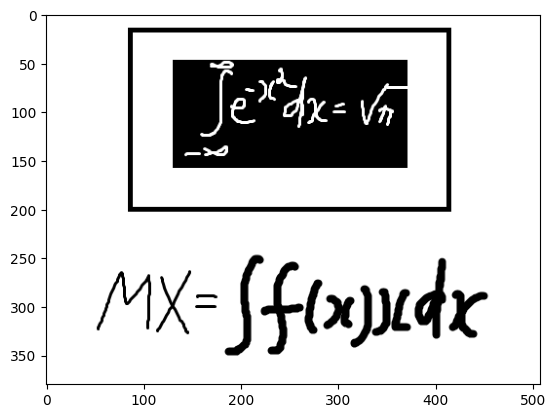

In [127]:
img = cv2.imread("pic.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap = 'gray')

In [ ]:
def erosion(image, kernel):
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    result = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+k_h, j:j+k_w]
            if np.all(region[kernel == 1] == 1):# якщо всі піксели під kernel білі, то білий  (fit)
                result[i, j] = 1

    return result

In [ ]:
def dilation(image, kernel):
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    result = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+k_h, j:j+k_w]
            if np.any(region[kernel == 1] == 1):# якщо хоч один піксель під kernel білий, то білий  (hit)
                result[i, j] = 1

    return result

In [130]:
def opening(image, kernel):
    #Розмикання - ерозія, потім дилатація
    eroded = erosion(image, kernel)
    result = dilation(eroded, kernel)
    return result

In [131]:
def closing(image, kernel):
    #Замикання - дилатація, потім ерозія
    dilated = dilation(image, kernel)
    result = erosion(dilated, kernel)
    return result

In [132]:
def boundaries(image, kernel):
    eroded = erosion(image, kernel)
    return image - eroded

In [133]:
kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)
def binarize(image, threshold=127):
    return (image > threshold).astype(np.uint8)

img = binarize(img)

In [134]:
ers = erosion(img, kernel)
dil = dilation(img, kernel)
opn = opening(img, kernel)
cls = closing(img, kernel)
bnd = boundaries(img, kernel)

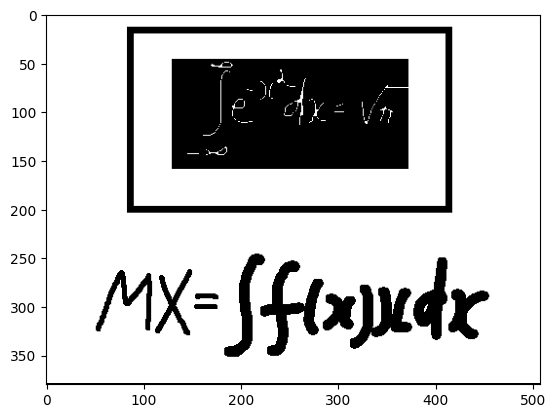

In [135]:
plt.imshow(ers, cmap='gray')

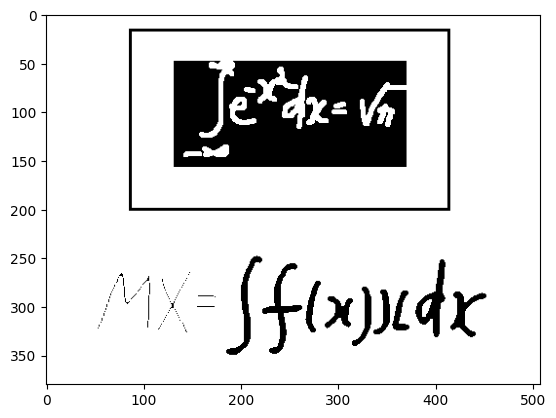

In [136]:
plt.imshow(dil, cmap='gray')

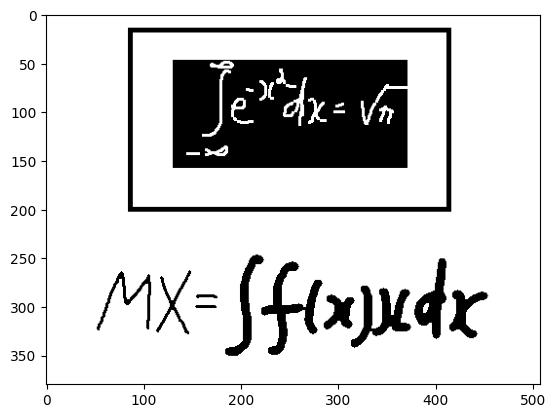

In [137]:
plt.imshow(opn, cmap='gray')

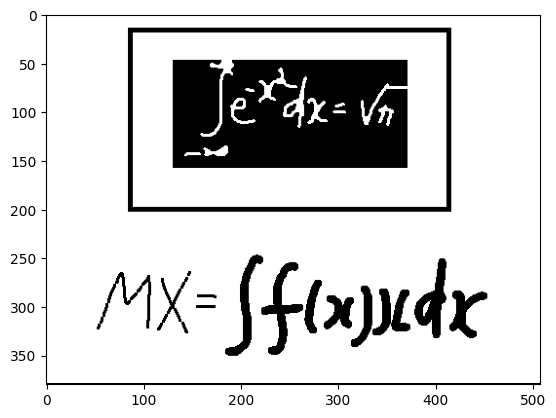

In [138]:
plt.imshow(cls, cmap='gray')

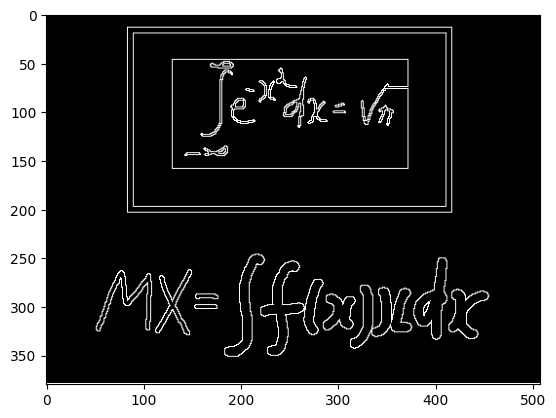

In [139]:
plt.imshow(bnd, cmap='gray')